In [1]:
from pathlib import Path
from torch import multiprocessing
import os
import torch
from tqdm import tqdm
import soundfile as sf

In [2]:
import numpy as np
import pandas as pd
import time
import io

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import colors
import datetime as dt

In [4]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
from pipeline import pipeline
from utils.utils import gen_empty_df
from cfg import get_config
from bat_detect.detector import models
import bat_detect.utils.detector_utils as du
import bat_detect.detector.compute_features as feats
import bat_detect.detector.post_process as pp
import bat_detect.utils.audio_utils as au

In [5]:
def run_models(file_mappings):
    """
    Runs the batdetect2 model to detect bat search-phase calls in the provided audio segments and saves detections into a .csv.

    Parameters
    ------------
    file_mappings : `List`
        - List of dictionaries generated by initialize_mappings()

    Returns
    ------------
    bd_dets : `pandas.DataFrame`
        - A DataFrame of detections that will also be saved in the provided output_dir under the above csv_name
        - 7 columns in this DataFrame: start_time, end_time, low_freq, high_freq, detection_confidence, event, input_file
        - Detections are always specified w.r.t their input_file; earliest start_time can be 0 and latest end_time can be 1795.
        - Events are always "Echolocation" as we are using a model that only detects search-phase calls.
    """

    bd_dets = pd.DataFrame()
    for i in tqdm(range(len(file_mappings))):
        cur_seg = file_mappings[i]
        bd_annotations_df = cur_seg['model']._run_batdetect(cur_seg['audio_seg']['audio_file'])
        bd_offsetted = pipeline._correct_annotation_offsets(
                bd_annotations_df,
                cur_seg['original_file_name'],
                cur_seg['audio_seg']['offset']
            )
        bd_dets = pd.concat([bd_dets, bd_offsetted])
        
    return bd_dets

def _apply_model(item):
    annotations_df = item['model']._run_batdetect(item['audio_seg']['audio_file'])
    return pipeline._correct_annotation_offsets(
        annotations_df,
        item['original_file_name'],
        item['audio_seg']['offset']
    )

def _apply_models(cfg, audio_segments):
    csv_names = []
    audio_file_path = cfg['audio_file']
    process_pool = multiprocessing.Pool(cfg['num_processes'])

    for model in cfg['models']:

        l_for_mapping = [{
            'audio_seg': audio_seg, 
            'model': model,
            'original_file_name': audio_file_path,
            } for audio_seg in audio_segments]

        pred_dfs = tqdm(
            process_pool.imap(_apply_model, l_for_mapping, chunksize=1), 
            desc=f"Applying {model.get_name()}",
            total=len(l_for_mapping),
        )

        agg_df = gen_empty_df() 
        agg_df = pd.concat(pred_dfs, ignore_index=True)

        csv_name = pipeline._generate_csv(agg_df, model.get_name(),
            audio_file_path.name,
            cfg['output_dir'],
            cfg['should_csv']
        )
        csv_names.append(csv_name)

    return csv_names

In [6]:
def run_pipeline_on_file(file, cfg):
    bd_preds = pd.DataFrame()

    if not cfg['output_dir'].is_dir():
        cfg['output_dir'].mkdir(parents=True, exist_ok=True)
    if not cfg['tmp_dir'].is_dir():
        cfg['tmp_dir'].mkdir(parents=True, exist_ok=True)

    cfg["csv_filename"] = f"batdetect2_pipeline_{file.name.split('.')[0]}"
    print(f"Generating detections for {file.name}")
    segmented_file_paths = batdetect2_pipeline.generate_segmented_paths([file], cfg)
    file_path_mappings = batdetect2_pipeline.initialize_mappings(segmented_file_paths, cfg)
    bd_preds = run_models(file_path_mappings)
    if cfg['save']:
        batdetect2_pipeline._save_predictions(bd_preds, cfg['output_dir'], cfg)
    batdetect2_pipeline.delete_segments(segmented_file_paths)

    return bd_preds

def apply_pipeline_on_file(file, cfg):
    bd_preds = pd.DataFrame()

    if not cfg['output_dir'].is_dir():
        cfg['output_dir'].mkdir(parents=True, exist_ok=True)
    if not cfg['tmp_dir'].is_dir():
        cfg['tmp_dir'].mkdir(parents=True, exist_ok=True)

    cfg["csv_filename"] = f"batdetect2_pipeline_{file.name.split('.')[0]}"
    print(f"Generating detections for {file.name}")
    segmented_file_paths = batdetect2_pipeline.generate_segmented_paths([file], cfg)
    file_path_mappings = batdetect2_pipeline.initialize_mappings(segmented_file_paths, cfg)
    bd_preds = _apply_models(cfg, file_path_mappings)
    if cfg['save']:
        batdetect2_pipeline._save_predictions(bd_preds, cfg['output_dir'], cfg)
    batdetect2_pipeline.delete_segments(segmented_file_paths)

    return bd_preds

In [7]:
input_file = Path('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')

cfg = get_config()
cfg['segment_duration'] = 30.0
cfg['input_audio'] = input_file
cfg['tmp_dir'] = Path('../output')
cfg['output_dir'] = Path('../output_dir')
cfg['run_model'] = True
cfg['num_processes'] = 4
cfg['should_csv'] = False
cfg['save'] = True

# apply_pipeline_on_file(input_file, cfg)
print(f"Generating detections for {input_file.name}")
segmented_file_paths = batdetect2_pipeline.generate_segmented_paths([input_file], cfg)
file_path_mappings = batdetect2_pipeline.initialize_mappings(segmented_file_paths, cfg)

Generating detections for 20220728_080000.WAV


In [8]:
torch.get_num_threads()

16

Parsing 16 chunks with 1 processors and 1 chunksize and 16 threads per processor


Applying BatDetect2:   0%|          | 0/60 [00:00<?, ?it/s]

Applying BatDetect2: 100%|██████████| 60/60 [03:07<00:00,  3.12s/it]


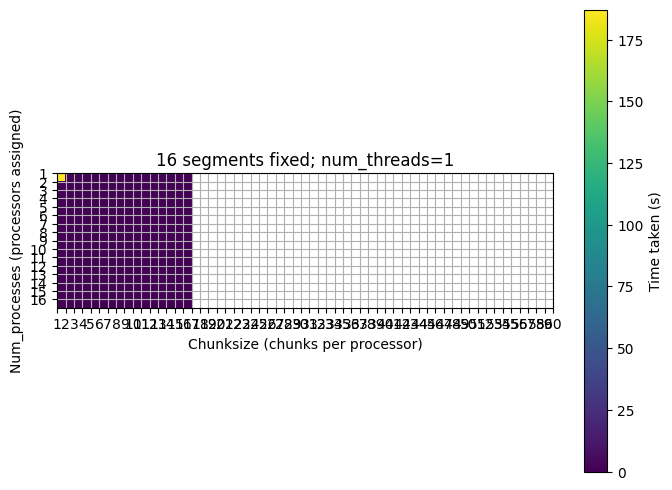

Parsing 16 chunks with 1 processors and 2 chunksize and 16 threads per processor


Applying BatDetect2: 100%|██████████| 60/60 [02:55<00:00,  2.93s/it]


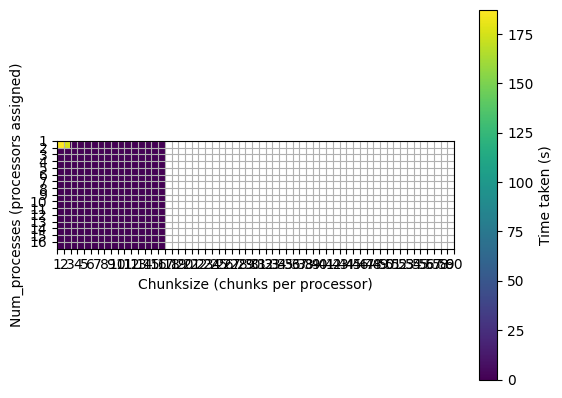

Parsing 16 chunks with 1 processors and 3 chunksize and 16 threads per processor


Applying BatDetect2:  22%|██▏       | 13/60 [00:47<02:35,  3.30s/it]

In [ ]:
input = file_path_mappings[:]
num_rows = min(len(input), multiprocessing.cpu_count())
num_cols = multiprocessing.cpu_count()
time_taken_test3 = np.zeros((num_rows, num_cols))
for i in range(num_rows):
    for j in range(num_cols):
        num_processes = int(i+1)
        default_num_threads_per_processor = torch.get_num_threads() # np.floor(multiprocessing.cpu_count()/num_processes).astype(int)
        num_threads_per_processor = np.floor(multiprocessing.cpu_count()/num_processes).astype(int)
        if num_threads_per_processor!=default_num_threads_per_processor:
            torch.set_num_threads(num_threads_per_processor)
        pool = multiprocessing.Pool(processes=num_processes)
        chunksize_custom = int(j+1)
        print(f'Parsing {num_cols} chunks with {num_processes} processors and {chunksize_custom} chunksize and {num_threads_per_processor} threads per processor')
        start = time.time()
        results = tqdm(pool.imap(_apply_model, input, chunksize=chunksize_custom), 
                        desc=f"Applying BatDetect2", total=len(input),)
        bd_preds = gen_empty_df() 
        bd_preds = pd.concat(results, ignore_index=True)
        end = time.time()
        time_taken_test3[i,j] = end-start

        plt.figure(figsize=(8,6))
        plt.title(f'{len(input)} segments fixed; num_threads=1')
        plt.imshow(time_taken_test3)
        plt.ylabel('Num_processes (processors assigned)')
        plt.xlabel('Chunksize (chunks per processor)')
        plt.yticks(np.arange(num_rows)-0.5, np.arange(num_rows)+1)
        plt.xticks(np.arange(num_cols)-0.5, np.arange(num_cols)+1)
        plt.grid(which='both')
        plt.colorbar(label='Time taken (s)')
        plt.show()

In [ ]:
time_taken_test3

array([[10.99675226, 21.27176738],
       [ 0.        ,  0.        ]])

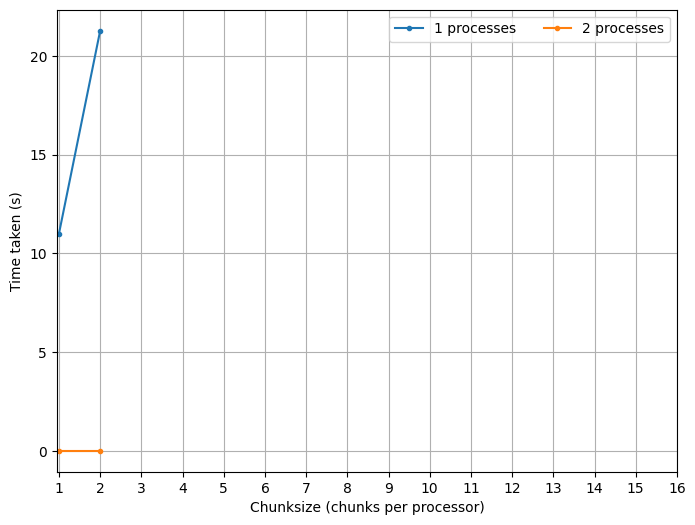

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(time_taken_test3.T, marker='.')
plt.xlabel('Chunksize (chunks per processor)')
plt.ylabel('Time taken (s)')
line_labs = []
for p in range(num_rows):
    line_labs+=[f'{int(p+1)} processes']
plt.legend(line_labs, ncols=2)
plt.xticks(np.arange(multiprocessing.cpu_count()), np.arange(multiprocessing.cpu_count())+1)
plt.grid(which='both')
plt.show()

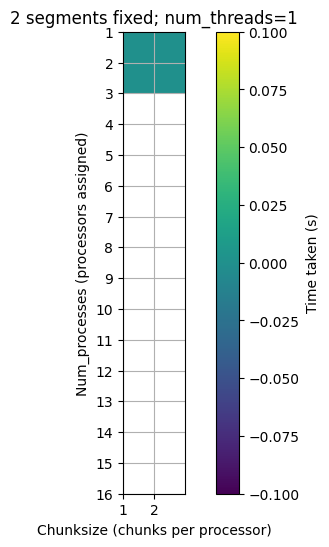

In [ ]:
plt.figure(figsize=(8,6))
plt.title(f'{len(input)} segments fixed; num_threads=1')
plt.imshow(time_taken_test3)
plt.ylabel('Num_processes (processors assigned)')
plt.xlabel('Chunksize (chunks per processor)')
plt.yticks(np.arange(multiprocessing.cpu_count())-0.5, np.arange(multiprocessing.cpu_count())+1)
plt.xticks(np.arange(len(input))-0.5, np.arange(len(input))+1)
plt.grid(which='both')
plt.colorbar(label='Time taken (s)')
plt.savefig(f'20241105__large_instance_single_file_computation')
plt.show()